In [5]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

from qas_statevec_4 import (
    kjall_disordered_ising_pauli_terms,
    x_moment_words_from_terms,
    build_basis_state_circuit,
)


In [6]:
L = 4          # número de qubits
K = L          # K-moment (pode mudar se quiser)
J = 1.0
J2 = 0.3
h = 0.6
deltaJ = 0.0   # aqui tanto faz, é só pra montar os termos
# rng = np.random.default_rng(1234)

# 1) Hamiltoniano em Pauli strings
terms, J_bonds = kjall_disordered_ising_pauli_terms(
    L=L,
    J=J,
    deltaJ=deltaJ,
    J2=J2,
    h=h,
    rng=None,
)

# 2) Palavras do conjunto CS_K (só X_i)
words = x_moment_words_from_terms(terms, L=L, K=K)

print(f"Número de palavras em CS_K: {len(words)}")
for i, w in enumerate(words[:10]):
    print(f"word {i}: {w}")
print("...")
print(f"última word (máxima): index {len(words)-1} -> {words[-1]}")


Número de palavras em CS_K: 16
word 0: ()
word 1: (5,)
word 2: (6,)
word 3: (7,)
word 4: (8,)
word 5: (5, 6)
word 6: (5, 7)
word 7: (5, 8)
word 8: (6, 7)
word 9: (6, 8)
...
última word (máxima): index 15 -> (5, 6, 7, 8)


word 0  (|0000⟩): ()
  -> salvo em: qas_basis_word_0.png
word 1  (~1 spin flip): (5,)
  -> salvo em: qas_basis_word_1.png
word 6  (~2 spin flips): (5, 7)
  -> salvo em: qas_basis_word_6.png
word 15 (todos X): (5, 6, 7, 8)
  -> salvo em: qas_basis_word_15.png


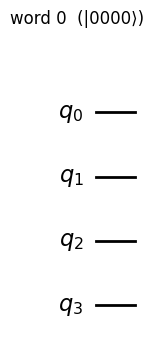

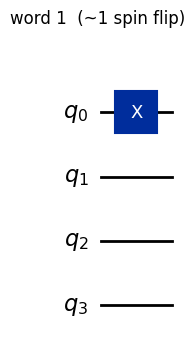

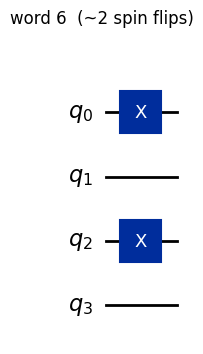

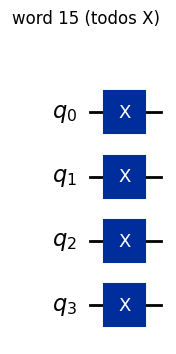

: 

In [ ]:
word_indices = [0, 1, 6, len(words) - 1]
labels = [
    "word 0  (|0000⟩)",
    "word 1  (~1 spin flip)",
    "word 6  (~2 spin flips)",
    f"word {len(words)-1} (todos X)",
]

for idx, label in zip(word_indices, labels):
    w = words[idx]
    print(f"{label}: {w}")

    qc = build_basis_state_circuit(L, terms, w)

    # desenha com mpl
    fig = qc.draw(output="mpl", fold=-1)
    fig.suptitle(label, y=1.02)

    # salva em alta resolução para usar no LaTeX
    fname = f"qas_basis_word_{idx}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    print("  -> salvo em:", fname)


In [4]:
fig.savefig(f"qas_circuit_L{L}_word{word_index}.png",
            dpi=300, bbox_inches="tight")

# se preferir PDF pro LaTeX:
# fig.savefig(f"qas_circuit_L{L}_word{word_index}.pdf",
#             bbox_inches="tight")